In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


**importing the libraries i want to use in this notebook**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Data exploring 
to see what we got there ! 

In [3]:
df = pd.read_csv(r'/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv(r'/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [6]:
numerical_cols = df.select_dtypes(include=[int,float]).columns
Categorical_cols = df.select_dtypes(include=[object]).columns
print(len(numerical_cols))
print(len(Categorical_cols))

38
43


In [7]:
df[Categorical_cols].head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


it seems like the train dataset contains 81 cols with 1460 record. and there is 1459 records for test dataset with 79 features.
the target value is Sale price
there is interesting features with huge null amount like PoolQC, MiscFeature , ...
we have 38 numercial cols and 43 categorical cols

In [8]:
df.isna().sum().sort_values(ascending = False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

# EDA

i want to see the distribution of the target value

<Axes: xlabel='SalePrice', ylabel='Count'>

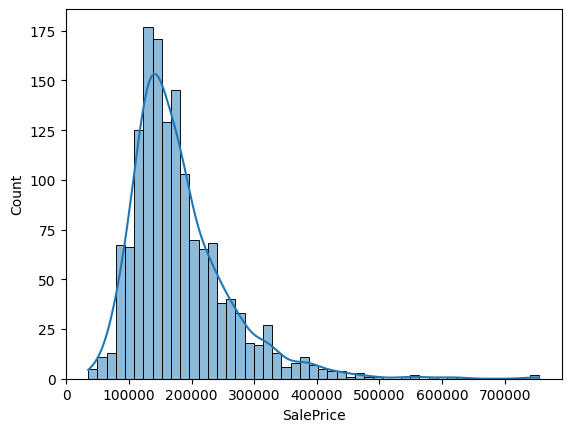

In [9]:
#look into our target 
sns.histplot(df['SalePrice'],kde=True)

In [10]:
print(df['SalePrice'].kurt())
print(df['SalePrice'].skew())

6.536281860064529
1.8828757597682129


as you can see the data has a tail and the skew is to the right side of the graph. most prices are between 100000 - 200000

<Axes: xlabel='SalePrice'>

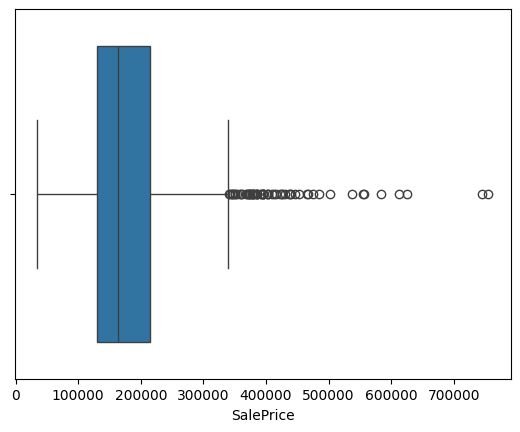

In [11]:
#observing the outliers
sns.boxplot(x=df['SalePrice'])

In [12]:
corr_matrix = df.corr(numeric_only=True)
sale_corr = corr_matrix['SalePrice'].sort_values(ascending = False)
sale_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

as you can see for the correlation of the data we have 
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
as top 3 correlated with sale price so lets explore them more

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

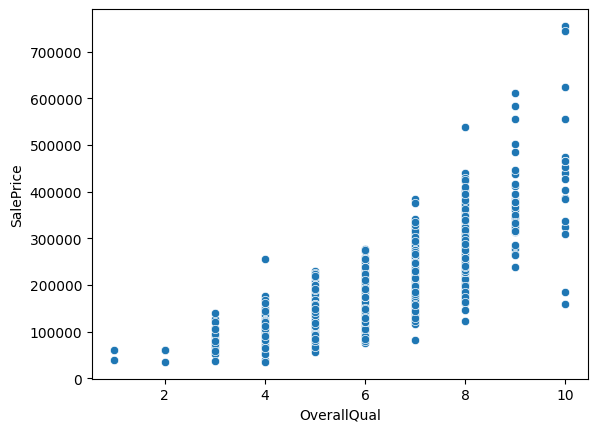

In [13]:
#overallqual VS SalePrice
sns.scatterplot(x=df['OverallQual'],y=df['SalePrice'])

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

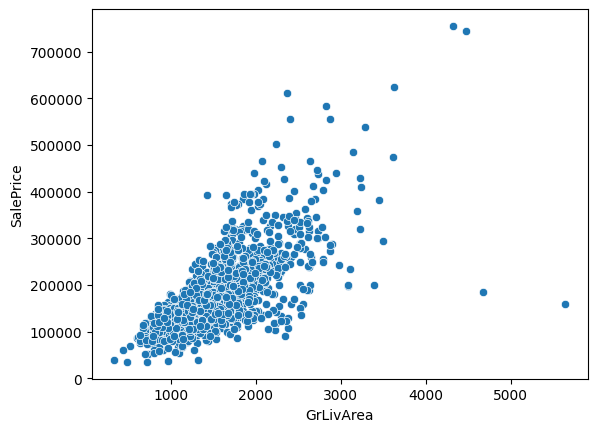

In [14]:
sns.scatterplot(x=df['GrLivArea'],y=df['SalePrice'])

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

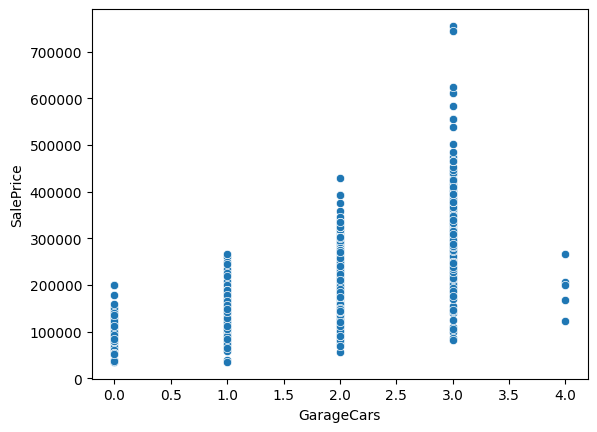

In [15]:
sns.scatterplot(x=df['GarageCars'],y=df['SalePrice'])

<Axes: xlabel='PavedDrive', ylabel='SalePrice'>

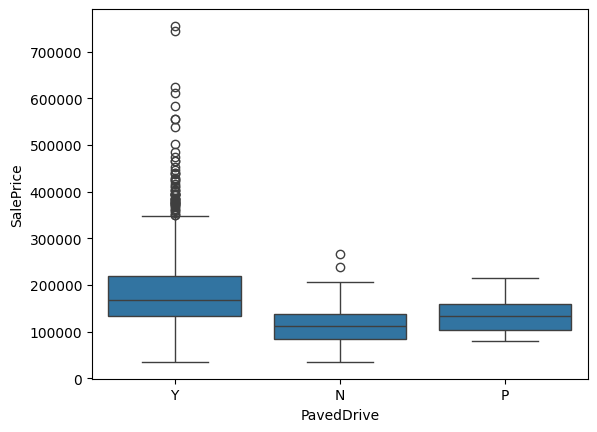

In [16]:
#just to see one of the categorical values that cought my eyes
sns.boxplot(x=df['PavedDrive'],y=df['SalePrice'])

<Axes: >

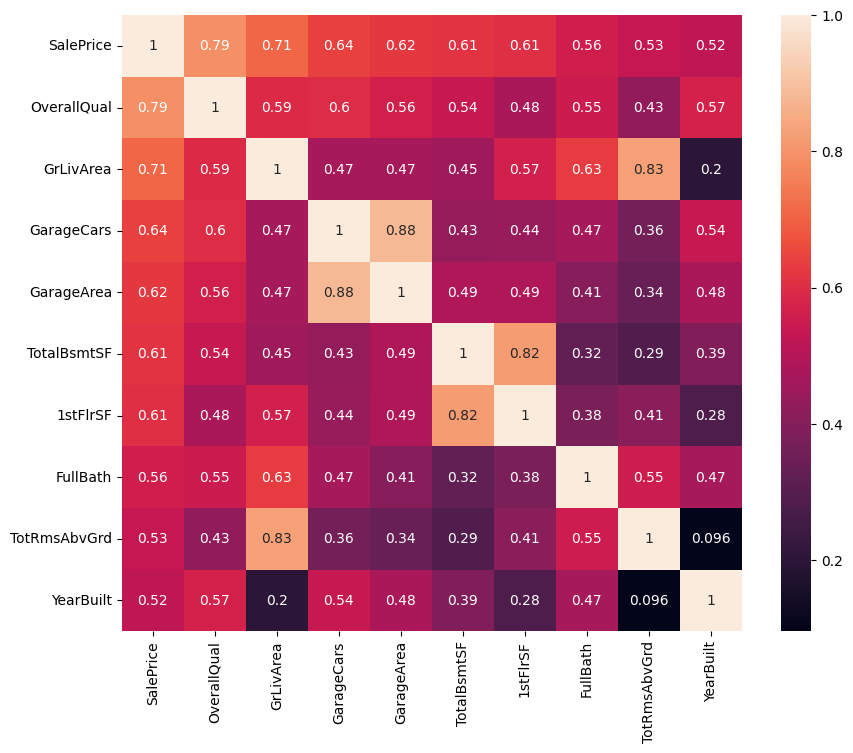

In [17]:
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending = False).head(10)
top_feature = top_corr.index
plt.figure(figsize=(10,8))
sns.heatmap(df[top_feature].corr(),annot=True)

# handelling missing values

In [18]:
#missing val
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent[missing_percent>0]
missing_percent.sort_values(ascending=False).head(15)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
dtype: float64

In [19]:
num_missing = df.select_dtypes(include=['int64', 'float64']).isnull().sum()

num_missing[num_missing > 0]

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

<Axes: xlabel='LotFrontage', ylabel='Count'>

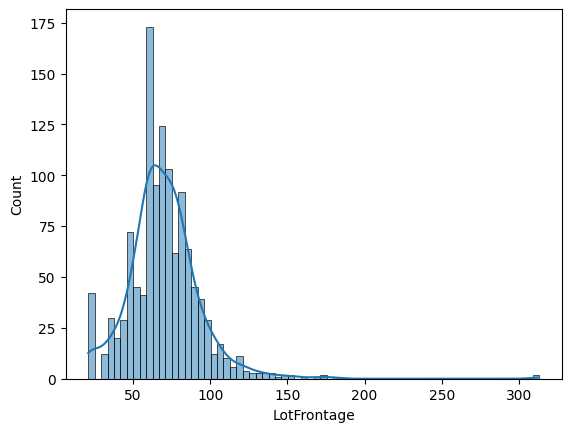

In [20]:
sns.histplot(df['LotFrontage'],kde=True)

In [21]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [22]:
df[df["MasVnrType"].isna()][["MasVnrArea"]].describe()

,MasVnrArea
count,864.000000
mean,1.094907
std,18.569659
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,344.000000


* for some of the values like pool or fence the absence of data means not having a pool or fence so i replace these cols with none to encode them later into zero
* other cols will be filled with mean or median

In [23]:
def fill_missing_values(df):
    cols = ['Alley','MasVnrType','FireplaceQu','Fence','PoolQC','GarageType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','GarageFinish','GarageQual','GarageCond','MiscFeature']
    for col in cols:
        df[col] = df[col].fillna("None")
    cat_col = ['Electrical','MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','Functional','SaleType']
    for cat in cat_col :
        df[cat]=df[cat].fillna(df[cat].mode()[0])
    df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())
    df['GarageYrBlt']=df['GarageYrBlt'].fillna(0)
    df.loc[df['MasVnrType']=='None','MasVnrArea']=0
    num_col = ['GarageCars','GarageArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
    for col in num_col :
        df[col]=df[col].fillna(0)
    return df

In [24]:
cleaned_df = fill_missing_values(df)
print(cleaned_df.isnull().sum().sort_values(ascending = False)[cleaned_df.isnull().sum()>0])

Series([], dtype: int64)


In [25]:
cleaned_test = fill_missing_values(df_test)
print(cleaned_test.isnull().sum().sort_values(ascending = False)[cleaned_test.isnull().sum()>0])

Series([], dtype: int64)


In [26]:
df_test_missing = df_test.isnull().sum()
missingcols = df_test_missing[df_test_missing>0].index
print(df_test[missingcols].dtypes)

Series([], dtype: object)


# encoding values

In [27]:
for col in [
    'ExterQual','KitchenQual',
    'BsmtQual','GarageQual',
    'FireplaceQu','PavedDrive',
    'GarageFinish'
]:
    print(col)
    print(cleaned_df[col].unique())
    print()

ExterQual
['Gd' 'TA' 'Ex' 'Fa']

KitchenQual
['Gd' 'TA' 'Ex' 'Fa']

BsmtQual
['Gd' 'TA' 'Ex' 'None' 'Fa']

GarageQual
['TA' 'Fa' 'Gd' 'None' 'Ex' 'Po']

FireplaceQu
['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']

PavedDrive
['Y' 'N' 'P']

GarageFinish
['RFn' 'Unf' 'Fin' 'None']



In [28]:
def encode_ordinal_features(df):
    qual_map = {
        'None' : 0,
        'Po':1,
        'Fa':2,
        'TA':3,
        'Gd':4,
        'Ex':5}
    paved_map = {
        'N':0,
        'P':1,
        'Y':2}
    Garage_map = {
        'None':0,
        'Unf':1,
        'RFn':2,
        'Fin':3}
    bsmt_fin_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6}
    qual_col = ['ExterQual','KitchenQual','BsmtQual','GarageQual','FireplaceQu','HeatingQC','ExterCond','BsmtCond','GarageCond']
    for col in qual_col:
        df[col]= df[col].map(qual_map)
    df['PavedDrive']=df['PavedDrive'].map(paved_map)
    df['GarageFinish']=df['GarageFinish'].map(Garage_map)
    df['BsmtFinType1']=df['BsmtFinType1'].map(bsmt_fin_map)
    df['BsmtFinType2']=df['BsmtFinType2'].map(bsmt_fin_map)
    return df

In [29]:
cleaned_df= encode_ordinal_features(cleaned_df)
cleaned_test=encode_ordinal_features(cleaned_test)

In [30]:
def leftcols(df):
    left_encoding_col = df.select_dtypes(include='object').columns
    print(len(left_encoding_col))
    print(left_encoding_col)

In [31]:
leftcols(cleaned_test)

30
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'Heating',
       'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')


In [32]:
leftcols(cleaned_df)

30
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'Heating',
       'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')


In [33]:
print(cleaned_df['BsmtFinType2'].unique())

[1 4 0 5 3 2 6]


concat the data because the number of features in test and train were different

In [34]:
all_df = pd.concat([cleaned_df,cleaned_test],axis=0)

In [35]:
cols4dummies = ['LandSlope', 'MasVnrType', 'BsmtExposure', 'PoolQC','MSZoning','Street','Alley','LotShape','LandContour','Utilities','LotConfig','Neighborhood','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','Foundation','Heating','CentralAir','Electrical','Functional','GarageType','MiscFeature','SaleType','SaleCondition','Fence']
all_df = pd.get_dummies(all_df,columns=cols4dummies,drop_first=True)
print(all_df.shape)
print(all_df.isnull().sum().sum())

(2919, 220)
1459


In [36]:
all_df['SalePrice'].isnull().sum()

np.int64(1459)

missing values are because of the target value sale price so im not in danger Lol

# feature engineering

In [37]:
#feature engineering 
all_df['TotalSF']=(all_df['TotalBsmtSF']+all_df['1stFlrSF']+all_df['2ndFlrSF'])
all_df['HouseAge']=all_df['YrSold'] - all_df['YearBuilt']
all_df['TotalBath']=all_df['FullBath']+all_df['HalfBath']*0.5 + all_df['BsmtFullBath'] + all_df['BsmtHalfBath']*0.5

In [38]:
#deconcat
train_df = all_df[all_df['SalePrice'].notnull()]
test_df=all_df[all_df['SalePrice'].isnull()]

# training

In [39]:
X = train_df.drop(['Id','SalePrice'],axis=1)
y = np.log1p(train_df['SalePrice'])
x_train ,x_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [40]:
model = XGBRegressor(n_estimators = 500,
                     learning_rate = 0.05,
                     max_depth = 3,
                     subsample = 0.7,
                     colsample_bytree = 0.8,
                     random_state = 42)
model.fit(x_train,y_train,eval_set=[(x_test,y_test)],verbose = 100)

[0]	validation_0-rmse:0.41818
[100]	validation_0-rmse:0.13728
[200]	validation_0-rmse:0.12974
[300]	validation_0-rmse:0.12909
[400]	validation_0-rmse:0.12986
[499]	validation_0-rmse:0.13049


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,pred))
print(rmse)

0.13049217664074725


In [42]:
test_X=test_df.drop(['Id','SalePrice'],axis=1,errors="ignore")
print(X.shape)
print(test_df.shape)

(1460, 221)
(1459, 223)


In [43]:
param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}
xgb = XGBRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
search.fit(X, y)
print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.7, 'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
-0.12539517580960627


In [44]:
#training all of my X data
finallmodel = XGBRegressor(n_estimators = 500,
                     learning_rate = 0.05,
                     max_depth = 3,
                     subsample = 0.7,
                     colsample_bytree = 0.8,
                     random_state = 42)
finallmodel.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
finalpreds = finallmodel.predict(test_X)
test_ids = test_df["Id"]
finalpreds = np.expm1(finalpreds)
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": finalpreds
})
submission.to_csv("submission.csv", index=False, encoding="utf-8")